# Session 03 - Distributions and Moments

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Intertangler/CB2330-exercises/blob/main/03_distributions_and_moments/exercise.ipynb)

In this exercise we will build the objects of the videos on a column of a count matrix: the reads of gene A, counted in 60 cells of a single-cell RNA-seq run. We will bin the counts, turn the bins into $\hat{p}(x)$, add $\hat{p}(x)$ up into $F(t)$, and then write the expected value $E(u(x))$ as a loop and get the mean, the variance, the skewness and the kurtosis out of it by changing $u$.

I've written the data, the check cells and the figure already.

**Deliverable:** this notebook, run, committed to `cb2330-portfolio`.

Part A leaves gaps in the functions, marked `⭐⭐⭐ Your code here ⭐⭐⭐`. The inputs and the return value of a function are given, and the gap is the body: the loop, and the arithmetic of the formula above it. The check cell below it says whether the fill is right.

## 0. The data

A count matrix has a row per gene and a column per cell. An entry below is the reads assigned to gene A in a cell, and the list runs over 60 cells.

$x_i$ is the count in cell $i$ and $N = 60$.

In [1]:
# ---- the data -------------------------------------------------------------
# Reads counted for gene A, one entry per cell.
gene_a = [3, 1, 4, 2, 3, 0, 2, 5, 3, 1,
          2, 4, 3, 2, 1, 6, 3, 2, 4, 3,
          0, 3, 2, 7, 4, 1, 3, 2, 5, 3,
          2, 1, 4, 3, 2, 0, 3, 6, 2, 4,
          1, 3, 5, 2, 3, 4, 2, 1, 3, 9,
          2, 3, 1, 4, 2, 3, 0, 5, 3, 2]

print("cells   ", len(gene_a))
print("smallest", min(gene_a), "  largest", max(gene_a))

cells    60
smallest 0   largest 9


---

# Part A

## 1. Binning

This section is aimed at binning: the same data can be partitioned in several ways, and the partition is a choice we make. We will count the reads into bins of width 1, 2, 5 and 10 and compare the shapes. With width 10 the shape is gone, and with width 1 no information is lost, because the counts are whole numbers.

Bin $b$ holds the values with $e_b \le x < e_{b+1}$:

$$n_b = \sum_{i=1}^{N} \mathbb{1}[\,e_b \le x_i < e_{b+1}\,]$$

The check cell adds the bin counts back up and compares them with $N$.

**Fill the gap to count the reads into bins.** `bin_counts` takes `data` and `edges` and returns `counts`, a list with a count per bin, set up as zeros. Write a loop over the bins with a loop over `data` inside it, and add 1 to `counts[b]` when `edges[b] <= value < edges[b + 1]`.

In [ ]:
# ---- binning --------------------------------------------------------------
def bin_counts(data, edges):
    """How many values fall in each bin.  Bin b is [edges[b], edges[b+1])."""
    counts = [0] * (len(edges) - 1)
    for value in data: # why second loope, can posibly write in forst loop?
        for b in range(len(edges) - 1):
            if edges[b] <= value < edges[b+1]:
                counts[b] += 1
    return counts


def show_bins(edges, counts):
    """One row per bin, drawn as a bar of #."""
    for b in range(len(counts)):
        label = f"{edges[b]:>3} to {edges[b + 1]:<3}"
        print(label, "|", "#" * counts[b], counts[b])
    print()


edges_1 = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]     # one bin per count
edges_2 = [0, 2, 4, 6, 8, 10]                    # two counts per bin
edges_5 = [0, 5, 10]                             # five counts per bin
edges_all = [0, 10]                              # everything in one bin

print("width 1"); show_bins(edges_1, bin_counts(gene_a, edges_1))
print("width 2"); show_bins(edges_2, bin_counts(gene_a, edges_2))
print("width 5"); show_bins(edges_5, bin_counts(gene_a, edges_5))
print("one bin"); show_bins(edges_all, bin_counts(gene_a, edges_all))

# Every value lands in exactly one bin, whatever the width.
for edges in [edges_1, edges_2, edges_5, edges_all]:
    assert sum(bin_counts(gene_a, edges)) == len(gene_a), edges
print("binning ok")

width 1
  0 to 1   | #### 4
  1 to 2   | ######## 8
  2 to 3   | ############### 15
  3 to 4   | ################# 17
  4 to 5   | ######## 8
  5 to 6   | #### 4
  6 to 7   | ## 2
  7 to 8   | # 1
  8 to 9   |  0
  9 to 10  | # 1

width 2
  0 to 2   | ############ 12
  2 to 4   | ################################ 32
  4 to 6   | ############ 12
  6 to 8   | ### 3
  8 to 10  | # 1

width 5
  0 to 5   | #################################################### 52
  5 to 10  | ######## 8

one bin
  0 to 10  | ############################################################ 60

binning ok


## 2. From counts to $\hat{p}(x)$

Here we turn the bin counts into probabilities. Dividing by $N$ gives the empirical distribution $\hat{p}(x)$, the share of cells at a count, and it assigns zero to a count absent from the sample.

A bin of width 1 is a count, so $n_x$ is the number of cells at count $x$:

$$\hat{p}(x) = \frac{n_x}{N}, \qquad \sum_x \hat{p}(x) = 1$$

**Fill the gap to turn the bin counts into probabilities.** `p_a` starts as zeros the length of `values`. Write the loop that sets `p_a[i]` to `n_seen[i]` divided by the number of cells.

In [19]:
# ---- from counts to probabilities -----------------------------------------
# The counts are whole numbers, so one bin per count loses nothing.
# Divide by the number of cells and the histogram becomes p(x).
values = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
n_seen = bin_counts(gene_a, edges_1)

p_a = [0.0] * len(values)
for i in range(len(values)):
    p_a[i] = n_seen[i] / len(gene_a)

total = 0.0
for i in range(len(p_a)):
    total = total + p_a[i]
assert abs(total - 1.0) < 1e-12, total
print("p(x)     ", p_a)
print("summing to", round(total, 12))

p(x)      [0.06666666666666667, 0.13333333333333333, 0.25, 0.2833333333333333, 0.13333333333333333, 0.06666666666666667, 0.03333333333333333, 0.016666666666666666, 0.0, 0.016666666666666666]
summing to 1.0


## 3. The distribution function

This section builds the distribution function, the running sum that turns probabilities into the probability of being at or below a threshold. We will build it twice: for the counts, by adding probabilities, and for a continuous variable, by adding up the area under a density. The continuous example is the time until a molecule binds its target, on a density I've chosen so that binding early is likelier than binding late.

$$F(t) = P\{x \le t\}$$

Discrete, a running sum of the probabilities up to $t$:

$$F(t) = \sum_{x_i \le t} p(x_i)$$

Continuous, the area under the density up to $t$, added up as $m$ rectangles of width $\Delta = t/m$:

$$F(t) = \int_0^t f(s)\,ds \;\approx\; \sum_{i=0}^{m-1} f(i\Delta)\,\Delta$$

The density here is a binding time on 0 to 2 seconds, $f(t) = (2 - t)/2$, in units of per second.

The check cell tests that $F$ ends at 1 and that $F$ is non-decreasing.

**Fill the gaps to build $F(t)$ for the counts and for the binding time.** In `cumulative_discrete`, `F` starts as zeros. Write the loop that sets `F[i]` to the running total of `ps` up to and including `ps[i]`. In `cumulative_continuous`, set up `width` as `t / n_steps` and `area` as zero, then write the loop over the `n_steps` rectangles that adds `f(x)` times `width` to `area`, with `x` the left edge of rectangle `i`.

In [31]:
# ---- adding it up: the distribution function ------------------------------
# F(t) = P(X < t).  Discrete: add the probabilities.  Continuous: add the area.

def cumulative_discrete(ps):
    """F(t) at each value, as a running total of the probabilities before it."""
    F = [0.0] * len(ps)
    for i in range(len(ps)):
        if i == 0:
            F[i] = ps[i]
        else:
            F[i] = F[i-1] + ps[i]
    return F


def density_binding(t):
    """f(t) for a binding time, in 1/seconds.  Zero outside 0 to 2 seconds."""
    if t < 0 or t > 2:
        return 0.0
    return (2 - t) / 2


def cumulative_continuous(f, t, n_steps):
    """F(t) = the area under `f` from 0 up to t, added up as n_steps rectangles."""
    width = t / n_steps
    area = 0
    for i in range(n_steps):
        x = i * width
        area += f(x) * width
    return area


F_a = cumulative_discrete(p_a)
print("discrete   ", F_a)
print("continuous  F(1.0) =", round(cumulative_continuous(density_binding, 1.0, 1000), 4))

# It ends at 1, because every outcome is below the largest threshold.
assert abs(F_a[-1] - 1.0) < 1e-12, F_a[-1]
assert abs(cumulative_continuous(density_binding, 2.0, 100000) - 1.0) < 1e-3

# It never goes down.
for i in range(1, len(F_a)):
    assert F_a[i] >= F_a[i - 1], (i, F_a[i], F_a[i - 1])
print("cumulative ok")

discrete    [0.06666666666666667, 0.2, 0.45, 0.7333333333333334, 0.8666666666666667, 0.9333333333333333, 0.9666666666666667, 0.9833333333333334, 0.9833333333333334, 1.0]
continuous  F(1.0) = 0.7503
cumulative ok


## 4. The plots

$\hat{p}(x)$ as bars, then $F(t)$ for the counts as a staircase and $F(t)$ for the binding time as a curve.

In [33]:
pip install matplotlib

  Using cached matplotlib-3.11.1-cp313-cp313-macosx_11_0_arm64.whl.metadata (80 kB)
  Using cached contourpy-1.3.3-cp313-cp313-macosx_11_0_arm64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.64.0-cp313-cp313-macosx_10_13_universal2.whl.metadata (123 kB)
  Using cached kiwisolver-1.5.1-cp313-cp313-macosx_11_0_arm64.whl.metadata (5.2 kB)
  Using cached pillow-12.3.0-cp313-cp313-macosx_11_0_arm64.whl.metadata (9.1 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached matplotlib-3.11.1-cp313-cp313-macosx_11_0_arm64.whl (9.3 MB)
Using cached contourpy-1.3.3-cp313-cp313-macosx_11_0_arm64.whl (274 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.64.0-cp313-cp313-macosx_10_13_universal2.whl (3.1 MB)
Using cached kiwisolver-1.5.1-cp313-cp313-macosx_11_0_arm64.whl (64 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 5.9 MB/s  0:00:00 eta 0:00:01
Using cached 

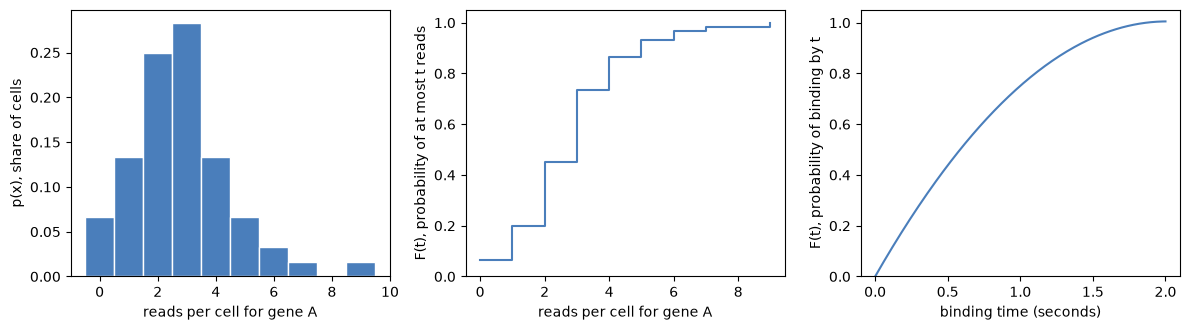

In [34]:
# ---- the plot -------------------------------------------------------------
import matplotlib.pyplot as plt

n_points = 201
ts = [0.0] * n_points
F_t = [0.0] * n_points
for i in range(n_points):
    ts[i] = i * 2 / (n_points - 1)
    F_t[i] = cumulative_continuous(density_binding, ts[i], 200)

fig, ax = plt.subplots(1, 3, figsize=(12, 3.4))

ax[0].bar(values, p_a, width=1.0, color="#4a7ebb", edgecolor="white")
ax[0].set_xlabel("reads per cell for gene A")
ax[0].set_ylabel("p(x), share of cells")

ax[1].step(values, F_a, where="post", color="#4a7ebb")
ax[1].set_xlabel("reads per cell for gene A")
ax[1].set_ylabel("F(t), probability of at most t reads")
ax[1].set_ylim(0, 1.05)

ax[2].plot(ts, F_t, color="#4a7ebb")
ax[2].set_xlabel("binding time (seconds)")
ax[2].set_ylabel("F(t), probability of binding by t")
ax[2].set_ylim(0, 1.05)

fig.tight_layout()
plt.show()

## 5. The expected value

The expected value is the construction of this section: a weighted sum whose weights are the probabilities, with $u$ as the quantity being averaged. We will write it as a loop once and reuse it for the rest of the notebook.

$$E\big(u(x)\big) = \sum_i u(x_i)\,p(x_i)$$

`expect` takes $u$ as a function, and from here on $u$ is what changes.

**Fill the gap to write $E(u(x))$ as a loop.** `expect` takes `u`, `xs` and `ps` and returns `total`. Start `total` at zero and add `u(xs[i]) * ps[i]` to it over `i`.

In [42]:
# ---- the one construction -------------------------------------------------
def expect(u, xs, ps):
    """E[u(X)] = sum over x of u(x) * p(x).  `u` is a function."""
    total = 0.0
    for i in range(len(xs)):
        total += u(xs[i]) * ps[i]
    return total

## 6. Choosing $u$

Here we write the choices of $u$ as functions, so that the mean and the central moments come out of the same `expect` with a different argument.

| $u(x)$ | $E(u(x))$ | In the code |
|---|---|---|
| $x$ | $\mu$, the mean | `u_value` |
| $x - \mu$ | $0$ | `u_deviation` |
| $(x-\mu)^2$ | $\sigma^2$, the variance | `u_square` |
| $(x-\mu)^3$ | $\mu'_3$ | `u_cube` |
| $(x-\mu)^4$ | $\mu'_4$ | `u_fourth` |

**Fill the gaps to define the $u$ of the central moments.** `u_value` and `u_deviation` are written and `mu` is computed above them. Write the bodies of `u_square`, `u_cube` and `u_fourth` from the table.

In [45]:
# ---- the choices of u -----------------------------------------------------
def u_value(x):
    """u(x) = x.  E of this is the mean."""
    return x


mu = expect(u_value, values, p_a)            # every u below is measured from mu


def u_deviation(x):
    """u(x) = x - mu.  E of this is zero: deviations cancel."""
    return x - mu


def u_square(x):
    """u(x) = (x - mu)^2.  E of this is the variance."""
    return (x - mu)**2


def u_cube(x):
    """u(x) = (x - mu)^3.  E of this is the third central moment."""
    return (x-mu)**3



def u_fourth(x):
    """u(x) = (x - mu)^4.  E of this is the fourth central moment."""
    return (x-mu)**4


## 7. The statistics

We will read the moments off as the statistics of gene A: $\mu$ and $\sigma$ in reads per cell, and $\gamma_1$ and $\beta_2$ as the shape.

$$\sigma = \sqrt{\sigma^2}, \qquad \gamma_1 = \frac{E\big((x-\mu)^3\big)}{\sigma^3}, \qquad \beta_2 = \frac{E\big((x-\mu)^4\big)}{\sigma^4}$$

$\sigma$ is back in reads per cell. $\gamma_1$ and $\beta_2$ are dimensionless.

**Fill the gaps to compute the statistics of gene A.** `first` and `variance` are given. Write `sigma`, `skewness` and `kurtosis` from the formulas above, using `expect` with `u_cube` and `u_fourth`.

In [46]:
# ---- the statistics, one call each ----------------------------------------
first = expect(u_deviation, values, p_a)
variance = expect(u_square, values, p_a)
sigma = (expect(u_square, values, p_a)) **0.5
skewness = expect(u_cube, values, p_a)
kurtosis = expect(u_fourth, values, p_a)

print(f"mean      {mu:.4f} reads per cell")
print(f"first     {first:.4f}   <- zero")
print(f"variance  {variance:.4f} reads^2")
print(f"sigma     {sigma:.4f} reads per cell")
print(f"skewness  {skewness:.4f}")
print(f"kurtosis  {kurtosis:.4f}")

mean      2.8167 reads per cell
first     -0.0000   <- zero
variance  2.9164 reads^2
sigma     1.7077 reads per cell
skewness  4.7268
kurtosis  40.4271


## 8. Checks

Here we check `expect` against numbers known before it runs.

- $\mu$ against $\bar{x} = \frac{1}{N}\sum_i x_i$, computed as a loop over the cells.
- $E(x - \mu) = 0$.
- $\sigma^2 = E(x^2) - \mu^2$, the other route to the variance.
- A Bernoulli with $\theta = 0.3$, where $\mu = \theta$ and $\sigma^2 = \theta(1-\theta)$.

In [47]:
# ---- checks ---------------------------------------------------------------
# The mean matches the arithmetic mean computed the long way.
arithmetic = 0.0
for count in gene_a:
    arithmetic = arithmetic + count
arithmetic = arithmetic / len(gene_a)
assert abs(mu - arithmetic) < 1e-12, (mu, arithmetic)

# The first central moment is zero.
assert abs(first) < 1e-12, first


# sigma^2 = E[X^2] - (E[X])^2, the other route to the same number.
def u_square_of_x(x):
    return x * x


assert abs(variance - (expect(u_square_of_x, values, p_a) - mu ** 2)) < 1e-12, variance

# A Bernoulli table, where the answers are known in closed form.
theta = 0.3
coin_values = [0, 1]
p_coin = [1 - theta, theta]
mu = expect(u_value, coin_values, p_coin)    # u_square reads mu, so set it first
assert abs(mu - theta) < 1e-12, mu
assert abs(expect(u_square, coin_values, p_coin) - theta * (1 - theta)) < 1e-12

print("checks ok")

checks ok


---

# Part B. $F(t)$ is an expectation too

In Part B the $u$ is an indicator: $F(t)$ and the probability of an interval are expected values of a $u$ that returns 0 or 1, so the same loop computes them.

Part B is optional and done outside the session.

$$P\{x < t\} = E\big(\mathbb{1}[\,x < t\,]\big)$$

`u_below` returns 1 below the threshold and 0 above it, so `expect` with this $u$ gives $F(t)$ back with no new code. For an interval:

$$P\{a \le x < b\} = E\big(\mathbb{1}[\,a \le x < b\,]\big) = F(b-1) - F(a-1)$$

**Fill the gaps to get probabilities out of `expect`.** Write the bodies of `u_below` and `u_between`: return 1 when the condition in the docstring holds and 0 when it doesn't.

In [52]:
# ---- Part B: F(t) is an expectation too -----------------------------------
# Pick a u that answers yes or no instead of returning a size.

threshold = 3


def u_below(x):
    """u(x) = 1 when x is below the threshold, 0 otherwise."""
    if x < threshold:
        u = 1
    else:
        u = 0
    return u


# Every value that counts contributes its own probability, and the rest contribute
# nothing, so the sum is P(X < t).  The same expect, a different u.
print(f"E[u_below] with t = {threshold}:", round(expect(u_below, values, p_a), 4))
print("cumulative_discrete gave:      ", round(F_a[threshold - 1], 4))
assert abs(expect(u_below, values, p_a) - F_a[threshold - 1]) < 1e-12

# So the whole curve can be rebuilt with expect and nothing else.
for t in range(1, len(values) + 1):
    threshold = t
    assert abs(expect(u_below, values, p_a) - F_a[t - 1]) < 1e-12, t
print("the whole of F(t) comes back out of expect")


# And once F(t) is an expectation, so is any interval.
low = 2
high = 5


def u_between(x):
    """u(x) = 1 when low <= x < high, 0 otherwise."""
    if x >= low and x < high:
        u = 1
    else:
        u = 0
    return u


p_interval = expect(u_between, values, p_a)
print(f"P({low} <= X < {high}) =", round(p_interval, 4))
assert abs(p_interval - (F_a[high - 1] - F_a[low - 1])) < 1e-12
print("Part B ok")

E[u_below] with t = 3: 0.45
cumulative_discrete gave:       0.45
the whole of F(t) comes back out of expect
P(2 <= X < 5) = 0.6667
Part B ok
